In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os

In [2]:
''' set paths '''
save_figs = f"../figures/targeting/"
data_folder = 'Z:/Isabel/histology/ctb_lhy/'

In [23]:
not_close = ['CHC158', 'LMN162', 'ONX98']

In [24]:
birds = []
files = os.listdir(data_folder)
for file in files:
    file_info = file.split('_')
    if len(file_info) <= 2:
        bird_id = file_info[0]
        if bird_id in not_close:
            continue
        birds.append(bird_id)

In [78]:
bird_colors = ['xkcd:brown', 'xkcd:sapphire', 'xkcd:red', 'xkcd:light gray', 'w', 'xkcd:light blue', 'xkcd:turquoise']
birds

['CHC62', 'IND104', 'ONX95', 'PRL83', 'PRL90', 'SPP38', 'TRQ39']

In [74]:
'''
For each bird:
- ML, DV, and AP error relative to LHY center
- head tilt
'''
# AP for injections
inj_coords_ap = np.asarray([
    [1.2, 1.5, 1.8], # CHC62
    [0.7, 1.1, 1.5], # IND104
    [0.6, 1.0, 1.4], # ONX95 - 53o
    [0.8, 1.2, 1.6], # PRL83
    [0.8, 1.2, 1.5], # PRL90
    [1.2, 1.5, 1.8], # SPP38
    [0.8, 1.2, 1.6] # TRQ39
])

# AP relative to LHY center: + is A, - is P
# within +/- 0.4 is still in LHY
# nan is not visible
lhy_coords_ap = np.asarray([
    [0.4, 0.6, 0.9], # CHC62
    [-0.5, -0.2, 0], # IND104
    [0.2, 0.4, 0.8], # ONX95
    [-0.2, 0.1, 0.6], # PRL83
    [np.nan, -0.7, -0.2], # PRL90
    [0.2, np.nan, np.nan], # SPP38
    [np.nan, -0.5, -0.3] # TRQ39 - est. slices are damaged
])

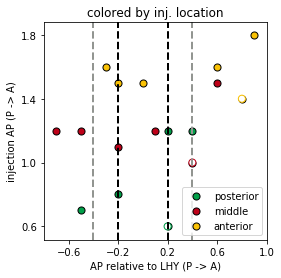

In [75]:
ctb_colors = ['xkcd:emerald', 'xkcd:scarlet', 'xkcd:goldenrod']
labels = ['posterior', 'middle', 'anterior']
DOT_SIZE = 50

f, ax = plt.subplots(1, 1, figsize=(4, 4))

for i in range(3):
    inj = inj_coords_ap[:, i]
    lhy = lhy_coords_ap[:, i]
    ax.scatter(lhy, inj,
               facecolors=ctb_colors[i], 
               edgecolors='k',
               s=DOT_SIZE, label=labels[i],
               zorder=0)
    
ax.scatter(lhy_coords_ap[2], inj_coords_ap[2],
           facecolors='w', edgecolors=ctb_colors,
           s=DOT_SIZE, zorder=1)

ax.set_xticks(np.arange(-1, 1.4, 0.4))
ax.set_yticks(np.arange(0.6, 2.2, 0.4))

ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.4, 0.4], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

ax.set_ylabel('injection AP (P -> A)')
ax.set_xlabel('AP relative to LHY (P -> A)')
ax.set_title('colored by inj. location')
plt.legend()

plt.show()

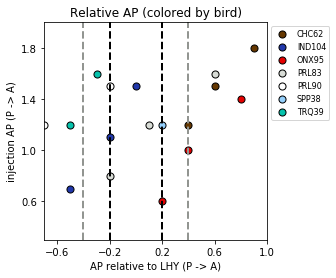

In [79]:
DOT_SIZE = 50

f, ax = plt.subplots(1, 1, figsize=(4, 4))

for i in range(len(birds)):
    inj = inj_coords_ap[i]
    lhy = lhy_coords_ap[i]
    ax.scatter(lhy, inj,
               s=DOT_SIZE,
               facecolors=bird_colors[i],
               edgecolors='k',
               label=birds[i],
               zorder=0) 

ax.set_xticks(np.arange(-1, 1.4, 0.4))
ax.set_yticks(np.arange(0.6, 2.2, 0.4))
ax.set_ylim([0.3, 2])
ax.set_xlim([-0.7, 1])

ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.4, 0.4], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

ax.set_ylabel('injection AP (P -> A)')
ax.set_xlabel('AP relative to LHY (P -> A)')
ax.set_title('Relative AP (colored by bird)')
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)

plt.show()

In [80]:
# DV for injections
inj_coords_dv = np.asarray([
    [-5.6, -5.4, -5.2], # CHC62
    [-6.4, -6.1, -5.8], # IND104
    [-6.4, -6.1, -5.8], # ONX95 - 53o
    [-6.4, -6.1, -5.8], # PRL83
    [-6, -5.7, -5.4], # PRL90
    [-5.7, -5.5, -5.3], # SPP38
    [-6, -5.7, -5.4] # TRQ39
])

# DV relative to LHY center: + is D, - is V
# within +/- 0.65 is still in LHY
# nan is not visible
lhy_coords_dv = np.asarray([
    [-0.3, -0.6, -0.4], # CHC62
    [0, 0, -0.4], # IND104 - est. slice is damaged
    [-1.1, -1.4, -0.7], # ONX95
    [-0.9, -1.1, -1.4], # PRL83
    [np.nan, 0.4, -0.6], # PRL90 - est. slice is damaged
    [0.1, np.nan, np.nan], # SPP38
    [np.nan, np.nan, np.nan] # TRQ39 - slices are too damaged
])

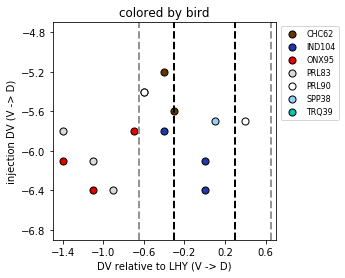

In [87]:
DOT_SIZE = 50

f, ax = plt.subplots(1, 1, figsize=(4, 4))

for i in range(len(birds)):
    inj = inj_coords_dv[i]
    lhy = lhy_coords_dv[i]
    ax.scatter(lhy, inj,
               s=DOT_SIZE,
               facecolors=bird_colors[i],
               edgecolors='k',
               label=birds[i],
               zorder=0)   

ax.set_xticks(np.arange(-1.4, 0.7, 0.4))
ax.set_yticks(np.arange(-6.8, -4.7, 0.4))
ax.set_ylim([-6.9, -4.7])
ax.set_xlim([-1.5, 0.7])

ylim = ax.get_ylim()
ax.vlines([-0.3, 0.3], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.65, 0.65], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

ax.set_ylabel('injection DV (V -> D)')
ax.set_xlabel('DV relative to LHY (V -> D)')
ax.set_title('Relative DV (colored by bird)')
plt.legend(bbox_to_anchor=(1.3,1,0,0), fontsize=8)

plt.show()

In [88]:
# ML for injections
inj_coords_ml = np.asarray([
    [0.4, 0.4, 0.4], # CHC62
    [0.4, 0.4, 0.4], # IND104
    [0.35, 0.35, 0.4], # ONX95 - 53o
    [0.4, 0.4, 0.35], # PRL83
    [np.nan, 0.4, 0.4], # PRL90
    [0.4, np.nan, np.nan], # SPP38
    [-6, -5.7, -5.4] # TRQ39
])

# ML relative to LHY center: + is L, - is M
# within +/- 0.35 is still in LHY
# nan is not visible
lhy_coords_ml = np.asarray([
    [0.1, 0.15, 0.1], # CHC62
    [0, 0.05, 0.1], # IND104 - est. slice is damaged
    [-0.2, 0.15, 0], # ONX95
    [0.15, 0.05, 0.4], # PRL83
    [np.nan, -0.14, 0.15], # PRL90 - est. slice is damaged
    [0.05, np.nan, np.nan], # SPP38
    [np.nan, np.nan, np.nan] # TRQ39 - slices are too damaged
])

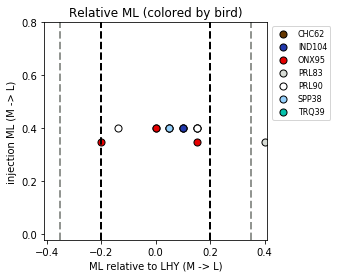

In [93]:
DOT_SIZE = 50

f, ax = plt.subplots(1, 1, figsize=(4, 4))

for i in range(len(birds)):
    inj = inj_coords_ml[i]
    lhy = lhy_coords_ml[i]
    ax.scatter(lhy, inj,
               s=DOT_SIZE,
               facecolors=bird_colors[i],
               edgecolors='k',
               label=birds[i],
               zorder=0)   

ax.set_xticks(np.arange(-0.4, 0.5, 0.2))
ax.set_yticks(np.arange(0, 0.9, 0.2))
ax.set_ylim([-0.02, 0.8])
ax.set_xlim([-0.41, 0.41])

ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.35, 0.35], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

ax.set_ylabel('injection ML (M -> L)')
ax.set_xlabel('ML relative to LHY (M -> L)')
ax.set_title('Relative ML (colored by bird)')
plt.legend(bbox_to_anchor=(1.3,1,0,0), fontsize=8)

plt.show()

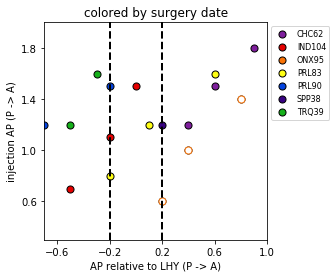

In [64]:
date_colors = ['xkcd:purple', 'xkcd:red', 'xkcd:orange', 'xkcd:yellow', 'xkcd:blue', 'xkcd:indigo', 'xkcd:green']
DOT_SIZE = 50

f, ax = plt.subplots(1, 1, figsize=(4, 4))

for i in range(len(birds)):
    inj = inj_coords_ap[i]
    lhy = lhy_coords_ap[i]
    ax.scatter(lhy, inj,
               s=DOT_SIZE,
               facecolors=date_colors[i],
               edgecolors='k',
               label=birds[i],
               zorder=0)

ax.scatter(lhy_coords_ap[2], inj_coords_ap[2],
           facecolors='w', edgecolors='xkcd:orange',
           s=DOT_SIZE, zorder=1)    

ax.set_xticks(np.arange(-1, 1.4, 0.4))
ax.set_yticks(np.arange(0.6, 2.2, 0.4))
ax.set_ylim([0.3, 2])
ax.set_xlim([-0.7, 1])

ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

ax.set_ylabel('injection AP (P -> A)')
ax.set_xlabel('AP relative to LHY (P -> A)')
ax.set_title('colored by surgery date')
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)

plt.show()

In [65]:
birds
11.82, 11.34, 9.85, 9.55, 10.67, 11.55, 10

['CHC62', 'IND104', 'ONX95', 'PRL83', 'PRL90', 'SPP38', 'TRQ39']

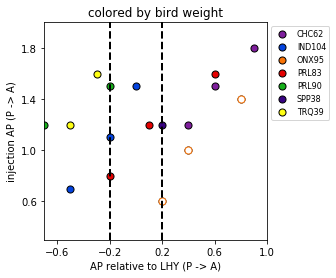

In [66]:
date_colors = ['xkcd:purple', 'xkcd:blue', 'xkcd:orange', 'xkcd:red', 'xkcd:green', 'xkcd:indigo', 'xkcd:yellow']
DOT_SIZE = 50

f, ax = plt.subplots(1, 1, figsize=(4, 4))

for i in range(len(birds)):
    inj = inj_coords_ap[i]
    lhy = lhy_coords_ap[i]
    ax.scatter(lhy, inj,
               s=DOT_SIZE,
               facecolors=date_colors[i],
               edgecolors='k',
               label=birds[i],
               zorder=0)

ax.scatter(lhy_coords_ap[2], inj_coords_ap[2],
           facecolors='w', edgecolors='xkcd:orange',
           s=DOT_SIZE, zorder=1)    

ax.set_xticks(np.arange(-1, 1.4, 0.4))
ax.set_yticks(np.arange(0.6, 2.2, 0.4))
ax.set_ylim([0.3, 2])
ax.set_xlim([-0.7, 1])

ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

ax.set_ylabel('injection AP (P -> A)')
ax.set_xlabel('AP relative to LHY (P -> A)')
ax.set_title('colored by bird weight')
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)

plt.show()